In [1]:
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv")
print(df.head())
print(df.info())

        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      0.00    6.871

In [2]:
print("First 5 Rows:")
print(df.head())


print("\nDataset Info:")
print(df.info())


print("\nMissing Values:")
print(df.isnull().sum())

print("\nColumn Names:")
print(df.columns)

First 5 Rows:
        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2     

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("SampleSuperstore.csv")

# Check null values
print(df.isnull().sum())

# Remove duplicates
df = df.drop_duplicates()

# Dataset information
print(df.info())
print(df.shape)

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 9976 entries, 0 to 9992
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9976 non-null   object 
 1   Segment       9976 non-null   object 
 2   Country       9976 non-null   object 
 3   City          9976 non-null   object 
 4   State         9976 non-null   object 
 5   Postal Code   9976 non-null   int64  
 6   Region        9976 non-null   object 
 7   Category      9976 non-null   object 
 8   Sub-Category  9976 non-null   object 
 9   Sales         9976 non-null   float64
 10  Quantity      9976 non-null   int64  
 11  Discount      9976 non-null   float64
 12  Profit        9976 non-null   float64
dtypes

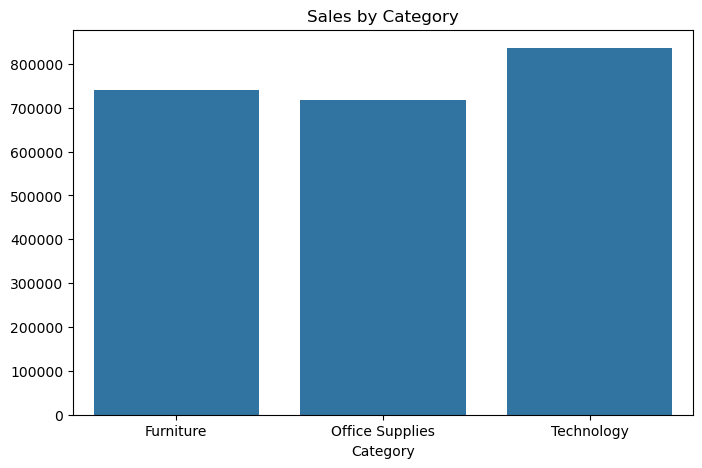

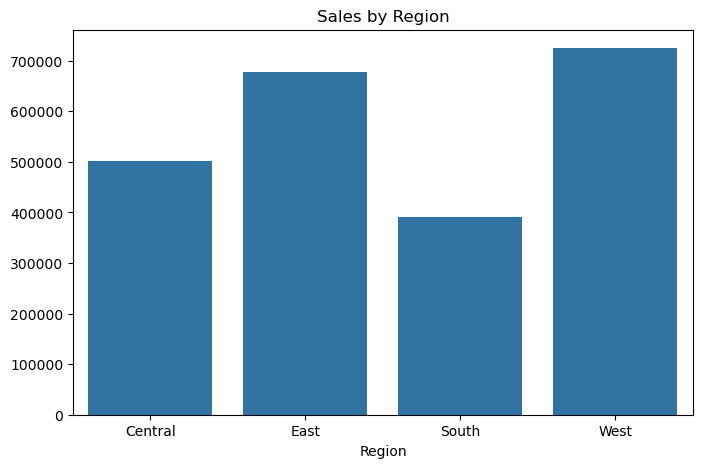

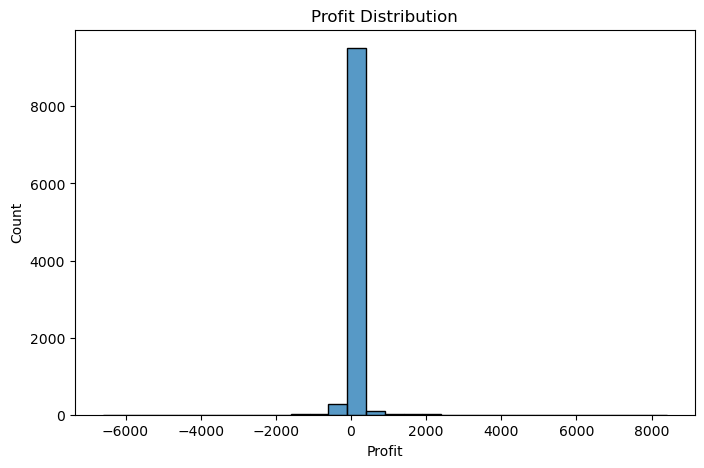

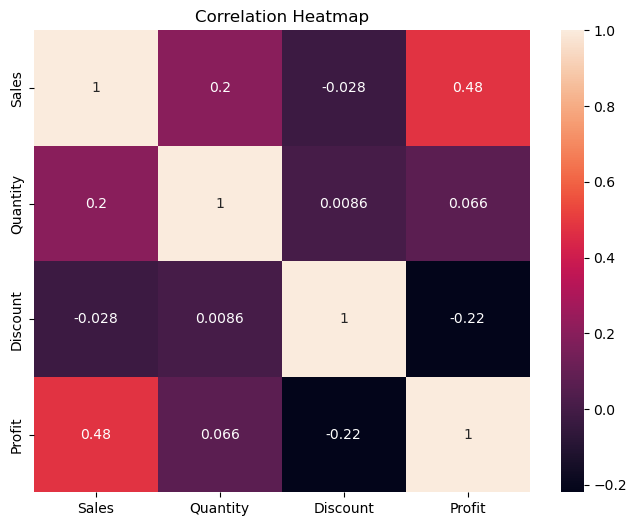

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sales by Category
plt.figure(figsize=(8,5))
sns.barplot(x=df.groupby('Category')['Sales'].sum().index,
            y=df.groupby('Category')['Sales'].sum().values)
plt.title("Sales by Category")
plt.show()

# Sales by Region
plt.figure(figsize=(8,5))
sns.barplot(x=df.groupby('Region')['Sales'].sum().index,
            y=df.groupby('Region')['Sales'].sum().values)
plt.title("Sales by Region")
plt.show()

# Profit Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['Profit'], bins=30)
plt.title("Profit Distribution")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(),
            annot=True)
plt.title("Correlation Heatmap")
plt.show()

C:\Users\sahaj\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\sahaj\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Users\sahaj\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\sahaj\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

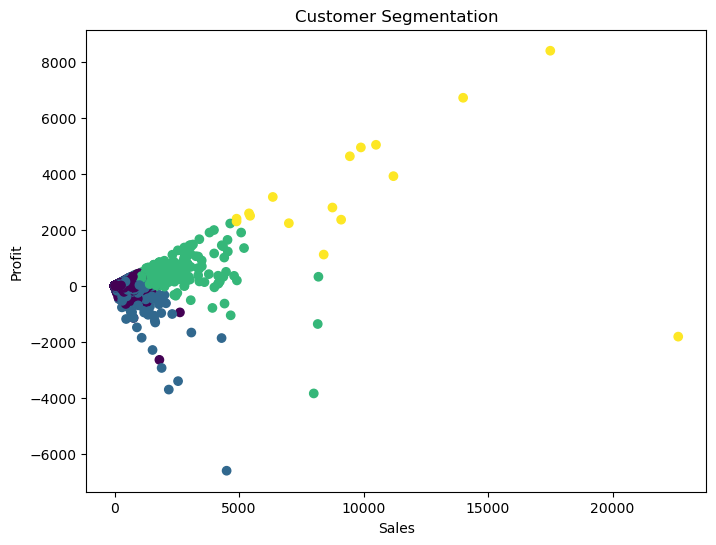

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

X = df[['Sales','Profit','Quantity']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(df['Sales'],
            df['Profit'],
            c=df['Cluster'])
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.title("Customer Segmentation")
plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X = df[['Quantity','Discount']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 247.490708604958
R2 Score: 0.05460619140935141


In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest R2:",
      r2_score(y_test, rf_pred))

Random Forest R2: 0.0868147348154773


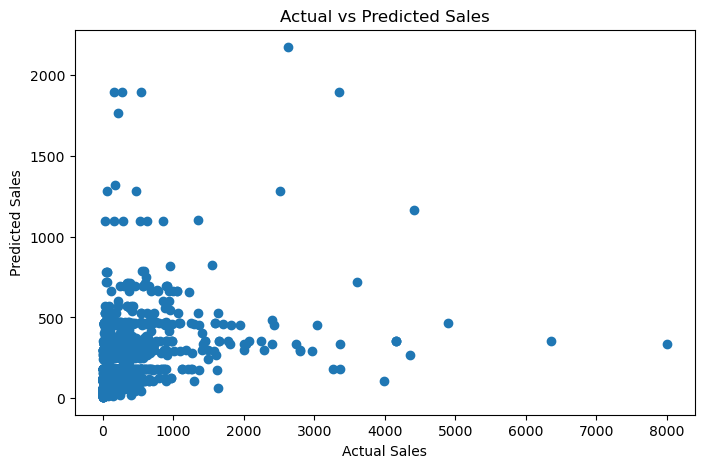

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [2]:
pip install shap

In [9]:
import pandas as pd

df = pd.read_csv("SampleSuperstore.csv")

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X = df[['Quantity', 'Discount']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

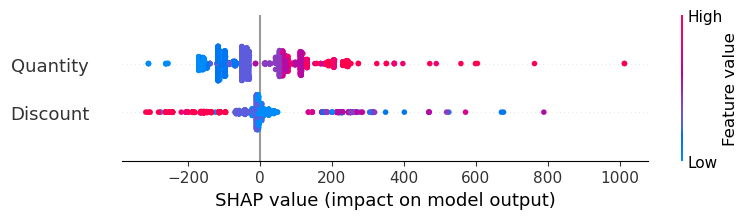

In [11]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)